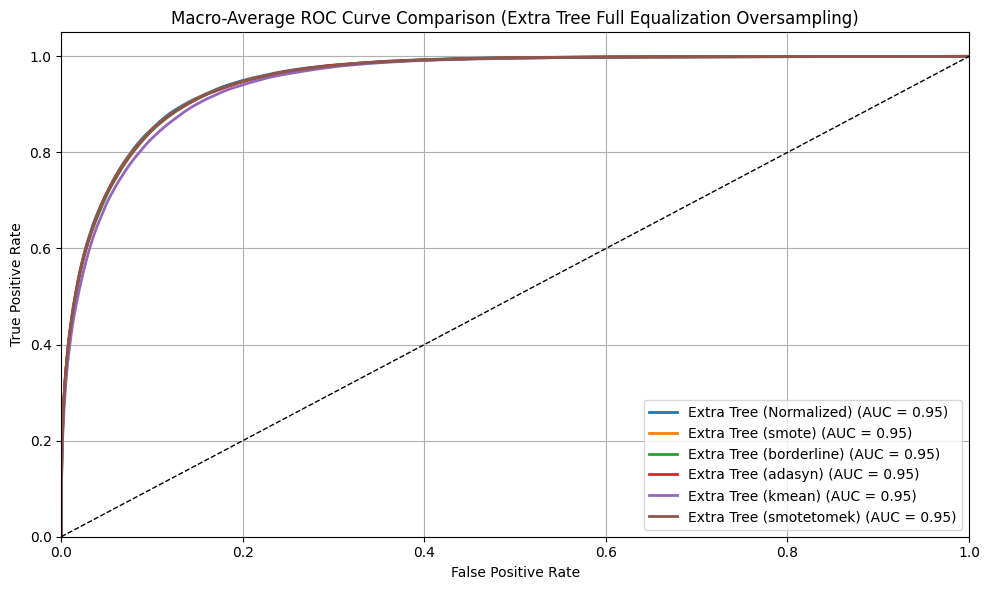

                     Model  Macro AUC
0  Extra Tree (Normalized)   0.952936
1       Extra Tree (smote)   0.952079
2  Extra Tree (borderline)   0.951824
3      Extra Tree (adasyn)   0.952165
4       Extra Tree (kmean)   0.947914
5  Extra Tree (smotetomek)   0.952072


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
#Some sampling
models = {
    'Extra Tree (Normalized)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ET.csv',
    'Extra Tree (smote)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETAllsmo.csv',
    'Extra Tree (borderline)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETAllbdl.csv',
    'Extra Tree (adasyn)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETAllads.csv',
    'Extra Tree (kmean)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETAllkmean.csv',
    'Extra Tree (smotetomek)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETAllsmotomek.csv',

}

plt.figure(figsize=(10, 6))
auc_summary = []

for model_name, file_path in models.items():
    df = pd.read_csv(file_path)
    cols = [c.lower() for c in df.columns]

    # --- ถ้ามี column class → ใช้ macro เท่านั้น
    if "class" in cols:
        df_macro = df[df[df.columns[cols.index("class")]] == "macro"]
        fpr = df_macro[df.columns[cols.index("fpr")]].values
        tpr = df_macro[df.columns[cols.index("tpr")]].values
    else:
        fpr = df[df.columns[cols.index("fpr")]].values
        tpr = df[df.columns[cols.index("tpr")]].values

    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {auc_score:.2f})')
    auc_summary.append([model_name, auc_score])

# baseline line
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison (Extra Tree Full Equalization Oversampling)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("ETall_ROC.png")
plt.show()

# --- export สรุป AUC เป็นไฟล์ ---
auc_df = pd.DataFrame(auc_summary, columns=["Model", "Macro AUC"])
auc_df.to_csv("ETall_ROC.csv", index=False)
print(auc_df)


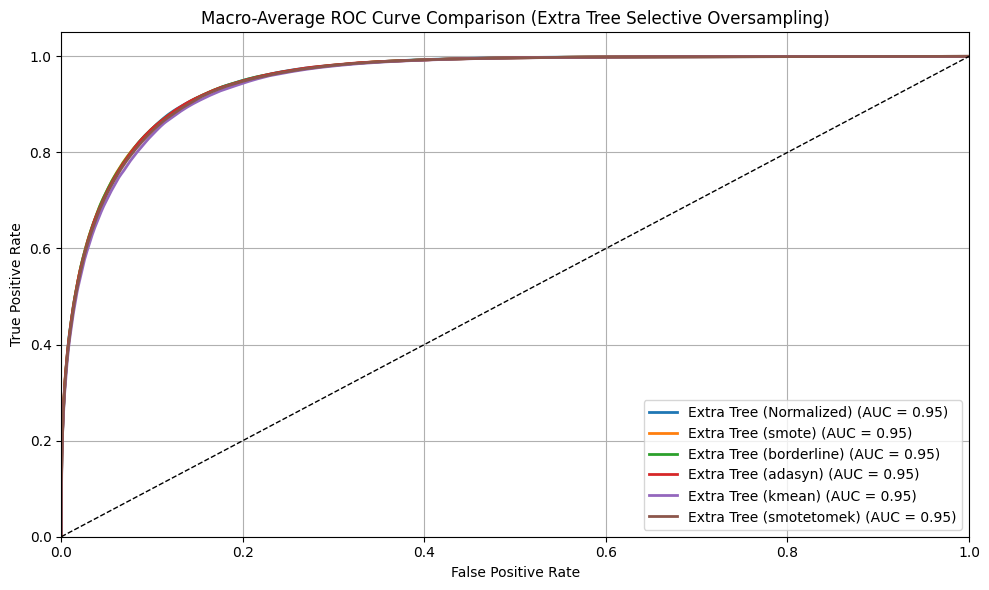

                     Model  Macro AUC
0  Extra Tree (Normalized)   0.952936
1       Extra Tree (smote)   0.952731
2  Extra Tree (borderline)   0.952857
3      Extra Tree (adasyn)   0.952786
4       Extra Tree (kmean)   0.949984
5  Extra Tree (smotetomek)   0.951808


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
#All sampling
models = {
    'Extra Tree (Normalized)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ET.csv',
    'Extra Tree (smote)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETSomesmo.csv',
    'Extra Tree (borderline)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETSomebdl.csv',
    'Extra Tree (adasyn)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETSomeads.csv',
    'Extra Tree (kmean)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETSomekmean.csv',
    'Extra Tree (smotetomek)': '/content/drive/MyDrive/Senior_Project/Model/ET/roc/roc_data_ETSomesmotomek.csv',

}

plt.figure(figsize=(10, 6))
auc_summary = []

for model_name, file_path in models.items():
    df = pd.read_csv(file_path)
    cols = [c.lower() for c in df.columns]

    # --- ถ้ามี column class → ใช้ macro เท่านั้น
    if "class" in cols:
        df_macro = df[df[df.columns[cols.index("class")]] == "macro"]
        fpr = df_macro[df.columns[cols.index("fpr")]].values
        tpr = df_macro[df.columns[cols.index("tpr")]].values
    else:
        fpr = df[df.columns[cols.index("fpr")]].values
        tpr = df[df.columns[cols.index("tpr")]].values

    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {auc_score:.2f})')
    auc_summary.append([model_name, auc_score])

# baseline line
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison (Extra Tree Selective Oversampling)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("ETsome_ROC.png")
plt.show()

# --- export สรุป AUC เป็นไฟล์ ---
auc_df = pd.DataFrame(auc_summary, columns=["Model", "Macro AUC"])
auc_df.to_csv("ETsome_ROC.csv", index=False)
print(auc_df)
